<a href="https://colab.research.google.com/github/July230/CopyCode/blob/develop/CopyCodeHNNModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [ ]:
import pandas as pd
import numpy as np
import os
import re
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Conv1D, Concatenate, Bidirectional, GRU, Dense, Dropout, GlobalMaxPooling1D, Layer, Embedding
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix as sk_confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from transformers import BertTokenizer, BertModel, RobertaTokenizer, RobertaModel, AutoTokenizer, AutoModel
from transformers import AutoTokenizer, AutoModel



In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Cargar Model

In [ ]:
def upload_model(new_path):
    new_model = tf.keras.models.load_model(
        new_path,
        custom_objects={"InceptionBlock": InceptionBlock}
    )
    return new_model

# Dataset

In [ ]:
parent_directory = "/content/drive/MyDrive/IA\ y\ Compiladores/Reto_plagio"
dataset_directory = os.path.join(parent_directory, "dataset")
# outputDirectory = os.path.join(parentDirectory, "BirdVSDrone")

<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_21434/612188922.py:1: SyntaxWarning: invalid escape sequence '\ '
  parent_directory = "/content/drive/MyDrive/IA\ y\ Compiladores/Reto_plagio"


In [ ]:
%cd {parent_directory}

/content/drive/MyDrive/IA y Compiladores/Reto_plagio


In [ ]:
%ls {dataset_directory}

checkpoint_m1/  dev_source.parquet   test_tokens.csv      train_source.parquet
dataset/        dev_tokens.csv       tokens_official.csv  train_tokens.csv
dev/            test/                train/               unlabeled_test.csv
dev.csv         test_source.parquet  train.csv


In [ ]:
%cd {dataset_directory}

/content/drive/MyDrive/IA y Compiladores/Reto_plagio/dataset


In [ ]:
train = pd.read_csv("train.csv")
train.head()

,uid,pid
0,415,27909
1,415,55938
2,415,90936
3,415,56858
4,415,9447


In [ ]:
train_tokens = pd.read_csv("train_tokens.csv")

In [ ]:
train_tokens

,chunk_id,token_ids,num_tokens,uid,pid
0,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,27909
1,1,"[101, 21189, 12879, 3940, 1026, 20014, 1010, 2...",512,415,27909
2,2,"[101, 11675, 1059, 1006, 9530, 3367, 1056, 100...",512,415,27909
3,3,"[101, 1045, 1011, 1011, 1007, 1063, 16360, 100...",407,415,27909
4,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,55938
...,...,...,...,...,...
95386,1,"[101, 8889, 8889, 8889, 8889, 8889, 2692, 1001...",507,276,3563
95387,0,"[101, 1001, 9375, 1035, 13675, 2102, 1035, 585...",512,276,75845
95388,1,"[101, 1011, 6694, 8889, 8889, 8889, 8889, 8889...",512,276,75845
95389,2,"[101, 1006, 1048, 2487, 1007, 1025, 16596, 100...",512,276,75845


In [ ]:
train_tokens_users = pd.merge(train_tokens, train, on="pid", how="inner")

In [ ]:
train_tokens_users_final = train_tokens_users.drop(columns=["uid_y"]).rename(columns={"uid_x": "uid"})

In [ ]:
train_tokens_users_final

,chunk_id,token_ids,num_tokens,uid,pid
0,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,27909
1,1,"[101, 21189, 12879, 3940, 1026, 20014, 1010, 2...",512,415,27909
2,2,"[101, 11675, 1059, 1006, 9530, 3367, 1056, 100...",512,415,27909
3,3,"[101, 1045, 1011, 1011, 1007, 1063, 16360, 100...",407,415,27909
4,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,55938
...,...,...,...,...,...
95386,1,"[101, 8889, 8889, 8889, 8889, 8889, 2692, 1001...",507,276,3563
95387,0,"[101, 1001, 9375, 1035, 13675, 2102, 1035, 585...",512,276,75845
95388,1,"[101, 1011, 6694, 8889, 8889, 8889, 8889, 8889...",512,276,75845
95389,2,"[101, 1006, 1048, 2487, 1007, 1025, 16596, 100...",512,276,75845


In [ ]:
dev = pd.read_csv("dev.csv")

In [ ]:
dev_tokens = pd.read_csv("dev_tokens.csv")

In [ ]:
dev_tokens

,chunk_id,token_ids,num_tokens,uid,pid
0,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,12180
1,1,"[101, 1028, 1060, 1025, 1065, 11675, 1035, 105...",512,415,12180
2,2,"[101, 1007, 1063, 6140, 2546, 1006, 1000, 1001...",322,415,12180
3,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,67901
4,1,"[101, 21189, 12879, 3940, 1026, 20014, 1010, 2...",512,415,67901
...,...,...,...,...,...
47349,1,"[101, 1011, 6694, 8889, 8889, 8889, 8889, 8889...",512,276,88752
47350,2,"[101, 1065, 2065, 1006, 999, 5210, 1007, 1063,...",210,276,88752
47351,0,"[101, 1001, 9375, 1035, 13675, 2102, 1035, 585...",512,276,81705
47352,1,"[101, 1045, 1033, 1012, 2117, 1027, 1045, 1025...",85,276,81705


In [ ]:
dev_tokens_users = pd.merge(dev_tokens, dev, on="pid", how="inner")

In [ ]:
dev_tokens_users_final = dev_tokens_users.drop(columns=["uid_y"]).rename(columns={"uid_x": "uid"})

In [ ]:
dev_tokens_users_final

,chunk_id,token_ids,num_tokens,uid,pid
0,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,12180
1,1,"[101, 1028, 1060, 1025, 1065, 11675, 1035, 105...",512,415,12180
2,2,"[101, 1007, 1063, 6140, 2546, 1006, 1000, 1001...",322,415,12180
3,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,67901
4,1,"[101, 21189, 12879, 3940, 1026, 20014, 1010, 2...",512,415,67901
...,...,...,...,...,...
47349,1,"[101, 1011, 6694, 8889, 8889, 8889, 8889, 8889...",512,276,88752
47350,2,"[101, 1065, 2065, 1006, 999, 5210, 1007, 1063,...",210,276,88752
47351,0,"[101, 1001, 9375, 1035, 13675, 2102, 1035, 585...",512,276,81705
47352,1,"[101, 1045, 1033, 1012, 2117, 1027, 1045, 1025...",85,276,81705


# Preparación de los datos

## Train

In [ ]:
VOCAB_SIZE = 30522
SEQ_LEN = 512

In [ ]:
def prepare_data(df):
  df_final = df.copy()
  print(type(df_final["token_ids"].iloc[0]))
  df_final["token_ids"] = df_final["token_ids"].apply(ast.literal_eval)
  print(type(df_final["token_ids"].iloc[0]))

  token_ids_padded = pad_sequences(
    df_final["token_ids"].tolist(),
    maxlen = SEQ_LEN,
    padding = "post",
    truncating = "post",
    value = 0  # [PAD] de BERT es 0
  )

  df_final["tokens_ids_padded"] = token_ids_padded.tolist()

  return df_final


In [ ]:
train_tokens_users_cleaned = prepare_data(train_tokens_users_final)

<class 'str'>
<class 'list'>


In [ ]:
dev_tokens_users_cleaned = prepare_data(dev_tokens_users_final)

<class 'str'>
<class 'list'>


In [ ]:
# test_tokens_users_cleaned = prepare_data(tokens_users_final)

Codificar la columna de uid

In [ ]:
label_encoder = LabelEncoder()
train_tokens_users_cleaned["uid_encoded"] = label_encoder.fit_transform(train_tokens_users_cleaned["uid"])

In [ ]:
train_tokens_users_cleaned

,chunk_id,token_ids,num_tokens,uid,pid,tokens_ids_padded,uid_encoded
0,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,27909,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",415
1,1,"[101, 21189, 12879, 3940, 1026, 20014, 1010, 2...",512,415,27909,"[101, 21189, 12879, 3940, 1026, 20014, 1010, 2...",415
2,2,"[101, 11675, 1059, 1006, 9530, 3367, 1056, 100...",512,415,27909,"[101, 11675, 1059, 1006, 9530, 3367, 1056, 100...",415
3,3,"[101, 1045, 1011, 1011, 1007, 1063, 16360, 100...",407,415,27909,"[101, 1045, 1011, 1011, 1007, 1063, 16360, 100...",415
4,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,55938,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",415
...,...,...,...,...,...,...,...
95386,1,"[101, 8889, 8889, 8889, 8889, 8889, 2692, 1001...",507,276,3563,"[101, 8889, 8889, 8889, 8889, 8889, 2692, 1001...",276
95387,0,"[101, 1001, 9375, 1035, 13675, 2102, 1035, 585...",512,276,75845,"[101, 1001, 9375, 1035, 13675, 2102, 1035, 585...",276
95388,1,"[101, 1011, 6694, 8889, 8889, 8889, 8889, 8889...",512,276,75845,"[101, 1011, 6694, 8889, 8889, 8889, 8889, 8889...",276
95389,2,"[101, 1006, 1048, 2487, 1007, 1025, 16596, 100...",512,276,75845,"[101, 1006, 1048, 2487, 1007, 1025, 16596, 100...",276


In [ ]:
x_train = train_tokens_users_cleaned["tokens_ids_padded"]
x_train = np.array(x_train.tolist())
x_train

array([[  101,  1013,  1008, ..., 25510,  1025,   102],
       [  101, 21189, 12879, ...,  1057,  1028,   102],
       [  101, 11675,  1059, ...,  1015,  1025,   102],
       ...,
       [  101,  1011,  6694, ...,  1025, 16596,   102],
       [  101,  1006,  1048, ...,  1065,  1065,   102],
       [  101,  2065,  1006, ...,     0,     0,     0]])

In [ ]:
y_train = train_tokens_users_cleaned["uid_encoded"]
y_train

,uid_encoded
0,415
1,415
2,415
3,415
4,415
...,...
95386,276
95387,276
95388,276
95389,276


## Dev/Val

In [ ]:
dev_tokens_users_cleaned["uid_encoded"] = label_encoder.transform(dev_tokens_users_cleaned["uid"])

In [ ]:
dev_tokens_users_cleaned

,chunk_id,token_ids,num_tokens,uid,pid,tokens_ids_padded,uid_encoded
0,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,12180,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",415
1,1,"[101, 1028, 1060, 1025, 1065, 11675, 1035, 105...",512,415,12180,"[101, 1028, 1060, 1025, 1065, 11675, 1035, 105...",415
2,2,"[101, 1007, 1063, 6140, 2546, 1006, 1000, 1001...",322,415,12180,"[101, 1007, 1063, 6140, 2546, 1006, 1000, 1001...",415
3,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",512,415,67901,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...",415
4,1,"[101, 21189, 12879, 3940, 1026, 20014, 1010, 2...",512,415,67901,"[101, 21189, 12879, 3940, 1026, 20014, 1010, 2...",415
...,...,...,...,...,...,...,...
47349,1,"[101, 1011, 6694, 8889, 8889, 8889, 8889, 8889...",512,276,88752,"[101, 1011, 6694, 8889, 8889, 8889, 8889, 8889...",276
47350,2,"[101, 1065, 2065, 1006, 999, 5210, 1007, 1063,...",210,276,88752,"[101, 1065, 2065, 1006, 999, 5210, 1007, 1063,...",276
47351,0,"[101, 1001, 9375, 1035, 13675, 2102, 1035, 585...",512,276,81705,"[101, 1001, 9375, 1035, 13675, 2102, 1035, 585...",276
47352,1,"[101, 1045, 1033, 1012, 2117, 1027, 1045, 1025...",85,276,81705,"[101, 1045, 1033, 1012, 2117, 1027, 1045, 1025...",276


In [ ]:
x_dev = dev_tokens_users_cleaned["tokens_ids_padded"]
x_dev = np.array(x_dev.tolist())
x_dev

array([[ 101, 1013, 1008, ..., 2078, 1028,  102],
       [ 101, 1028, 1060, ..., 1012, 1012,  102],
       [ 101, 1007, 1063, ...,    0,    0,    0],
       ...,
       [ 101, 1001, 9375, ..., 2099, 1031,  102],
       [ 101, 1045, 1033, ...,    0,    0,    0],
       [ 101, 1001, 2421, ...,    0,    0,    0]])

In [ ]:
y_dev = dev_tokens_users_cleaned["uid_encoded"]
y_dev

,uid_encoded
0,415
1,415
2,415
3,415
4,415
...,...
47349,276
47350,276
47351,276
47352,276


# Modelo

In [ ]:
EMB_DIM = 512
SEQ_LEN = 512
N_AUTORES = 1000
BATCH_SIZE = 16
DROPOUT = 0.2
EPOCHS = 16

In [ ]:
class InceptionBlock(Layer):
  def __init__(self, **kwargs):
    super().__init__(**kwargs)
    self.c1 = Conv1D(64, kernel_size=1, activation="relu", padding="same")
    self.c2 = Conv1D(128, kernel_size=3, activation="relu", padding="same")
    self.c3 = Conv1D(256, kernel_size=5, activation="relu", padding="same")
    self.concat = Concatenate()

  def call(self, x):
    return self.concat([self.c1(x), self.c2(x), self.c3(x)])

In [ ]:
def get_model_compiled():
  model = Sequential()
  model.add(Input(shape=(SEQ_LEN,), dtype="int32"))
  model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMB_DIM, mask_zero=True))
  model.add(InceptionBlock())
  model.add(Bidirectional(GRU(128)))
  model.add(Dense(512, activation='relu'))
  model.add(Dropout(DROPOUT))
  model.add(Dense(512, activation='relu'))
  model.add(Dropout(DROPOUT))
  model.add(Dense(N_AUTORES, activation='softmax'))

  model.compile(
      loss = "sparse_categorical_crossentropy",
      optimizer = optimizers.AdamW(learning_rate=1e-4),
      metrics = ["accuracy"]
  )
  return model

In [ ]:
%cd {parent_directory}

/content/drive/MyDrive/IA y Compiladores/Reto_plagio


In [ ]:
!mkdir "models"

mkdir: cannot create directory ‘models’: File exists


In [ ]:
models_directory = os.path.join(parent_directory, "models")

In [ ]:
base_dir = 'models'
checkpoint_path_best = os.path.join(base_dir, "HNN_Model", "HNN_Model.keras")
checkpoint_best = ModelCheckpoint(filepath= checkpoint_path_best,
                                  save_weights_only = False,
                                  save_freq = "epoch",
                                  monitor = "accuracy",
                                  save_best_only = True,
                                  verbose = 1)

In [ ]:
hnn_model = get_model_compiled()
hnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'inception_block' (of type InceptionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 512, 512)       │    15,627,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_block                 │ (None, 512, 448)       │       885,184 │
│ (InceptionBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       443,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │       513,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,863,592 (68.14 MB)

 Trainable params: 17,863,592 (68.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
x_train.shape

(95391, 512)

In [ ]:
y_train.shape

(95391,)

In [ ]:
hnn_model_uploaded = upload_model("/content/drive/MyDrive/IA y Compiladores/Reto_plagio/models/HNN_Model/HNN_Model3.0.0.keras")
hnn_model_uploaded.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'inception_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 512, 512)       │    15,627,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_block                 │ (None, 512, 448)       │       885,184 │
│ (InceptionBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       443,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │       513,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,590,778 (204.43 MB)

 Trainable params: 17,863,592 (68.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,727,186 (136.29 MB)

In [ ]:
hnn_history = hnn_model_uploaded.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    validation_data=(x_dev, y_dev),
    callbacks = [checkpoint_best],
    epochs=EPOCHS)

Epoch 1/16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_3' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_4' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_5' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


5962/5962 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9013 - loss: 0.3844
Epoch 1: accuracy improved from None to 0.89818, saving model to models/HNN_Model/HNN_Model.keras

Epoch 1: finished saving model to models/HNN_Model/HNN_Model.keras
5962/5962 ━━━━━━━━━━━━━━━━━━━━ 453s 75ms/step - accuracy: 0.8982 - loss: 0.3963 - val_accuracy: 0.6862 - val_loss: 3.6745
Epoch 2/16
5962/5962 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9073 - loss: 0.3601
Epoch 2: accuracy improved from 0.89818 to 0.90252, saving model to models/HNN_Model/HNN_Model.keras

Epoch 2: finished saving model to models/HNN_Model/HNN_Model.keras
5962/5962 ━━━━━━━━━━━━━━━━━━━━ 460s 77ms/step - accuracy: 0.9025 - loss: 0.3797 - val_accuracy: 0.6877 - val_loss: 3.8840
Epoch 3/16
5962/5962 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9099 - loss: 0.3511
Epoch 3: accuracy improved from 0.90252 to 0.90543, saving model to models/HNN_Model/HNN_Model.keras

Epoch 3: finished saving model to models/HNN_Model/HNN_Model.ke

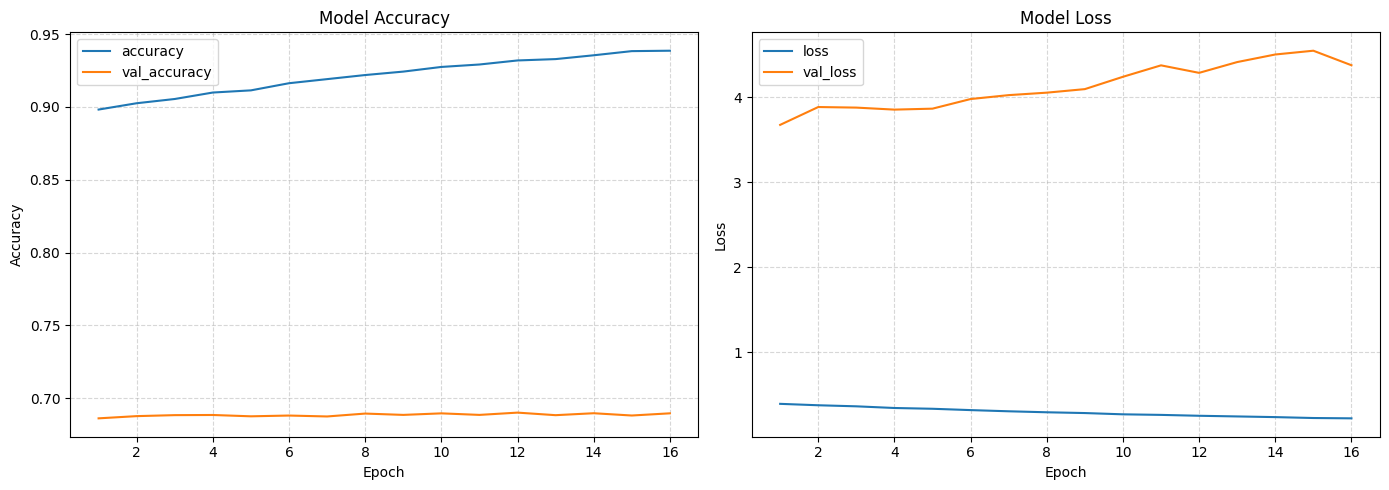

In [ ]:
accuracy     = hnn_history.history["accuracy"]
val_acc = hnn_history.history["val_accuracy"]
loss     = hnn_history.history["loss"]
val_loss = hnn_history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
ax1.plot(epochs, accuracy,     label="accuracy")
ax1.plot(epochs, val_acc, label="val_accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Loss ---
ax2.plot(epochs, loss,     label="loss")
ax2.plot(epochs, val_loss, label="val_loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
for layer in hnn_model.layers:
    print(layer.name, layer.output)

embedding <KerasTensor shape=(None, 512, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>
inception_block <KerasTensor shape=(None, 512, 448), dtype=float32, sparse=False, ragged=False, name=keras_tensor_6>
bidirectional <KerasTensor shape=(None, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_10>
dense <KerasTensor shape=(None, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_15>
dropout <KerasTensor shape=(None, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_21>
dense_1 <KerasTensor shape=(None, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_28>
dropout_1 <KerasTensor shape=(None, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_36>
dense_2 <KerasTensor shape=(None, 1000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_45>


In [ ]:
feature_extractor = Model(
    inputs  = hnn_model.inputs,
    outputs = hnn_model.get_layer("bidirectional").output
)

In [ ]:
code_embeddings = feature_extractor.predict(x_train)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_2' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


2981/2981 ━━━━━━━━━━━━━━━━━━━━ 79s 26ms/step


In [ ]:

reduced = TSNE(n_components=2, random_state=42).fit_transform(code_embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=y_train, cmap="tab20", s=10)
plt.colorbar(scatter, label="autor")
plt.title("Embeddings de código por autor")
plt.show()

KeyboardInterrupt: 

In [ ]:
# Crear dataframe — una columna por dimensión
cols = [f"emb_{i}" for i in range(code_embeddings.shape[1])]
df_embeddings = pd.DataFrame(code_embeddings, columns=cols)

# Agregar columnas de referencia
df_embeddings["uid"] = train_tokens_users_cleaned["uid"].values
df_embeddings["pid"] = train_tokens_users_cleaned["pid"].values

# Guardar
df_embeddings.to_csv("code_embeddings.csv", index=False)

# Diagnóstico

## Métricas

In [ ]:
def get_confusion_matrix(model, x_data, y_true, class_names=None):
    """
    Creates the confusion matrix for multi-class classification.
    Parameters
    ----------
    model : keras.Model
    x_data : np.ndarray
        Input data (token_ids, etc.)
    y_true : np.ndarray
        True labels (integers 0..N)
    class_names : list, optional
        Names of the classes. If None, uses integers.
    Returns
    -------
    matrix : np.ndarray
        Confusion matrix of shape (n_classes, n_classes)
    """
    predictions = model.predict(x_data, batch_size=32, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)  # multiclass → argmax

    matrix = sk_confusion_matrix(y_true, predicted_classes)

    n_classes = matrix.shape[0]
    labels = class_names if class_names else [str(i) for i in range(n_classes)]

    # Imprimir resumen por clase
    print(f"{'Clase':<20} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>8}")
    print("-" * 50)
    for i in range(n_classes):
        tp = matrix[i, i]
        fp = matrix[:, i].sum() - tp   # columna i, sin la diagonal
        fn = matrix[i, :].sum() - tp   # fila i, sin la diagonal
        tn = matrix.sum() - tp - fp - fn
        print(f"{labels[i]:<20} {tp:>6} {fp:>6} {fn:>6} {tn:>8}")

    return matrix, predicted_classes

def display_confusion_matrix(matrix, class_names=None, figsize=(12, 10)):
    """
    Displays the confusion matrix with color map.
    Parameters
    ----------
    matrix : np.ndarray
    class_names : list, optional
    figsize : tuple

    Returns
    -------
    None
    """
    n_classes = matrix.shape[0]
    labels = class_names if class_names else [str(i) for i in range(n_classes)]

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=figsize)
    display.plot(
        ax=ax,
        cmap="Blues",
        colorbar=True,
        xticks_rotation=45
    )
    plt.title("Confusion Matrix (Multi-class)")
    plt.tight_layout()
    plt.show()



In [ ]:
def metrics(matrix, class_names=None, average="macro"):
    """
    Calculates per-class and global metrics from a confusion matrix.
    Supports macro, micro and weighted averaging.
    Parameters
    ----------
    matrix : np.ndarray
        Confusion matrix of shape (n_classes, n_classes)
    class_names : list, optional
    average : str
        "macro"    → mean of per-class metrics (treats all classes equally)
        "micro"    → global TP/FP/FN (biased toward frequent classes)
        "weighted" → weighted by number of real samples per class
    Returns
    -------
    None
    """
    n_classes = matrix.shape[0]
    labels    = class_names if class_names else [str(i) for i in range(n_classes)]

    per_class = []

    print(f"\n{'Clase':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 72)

    for i in range(n_classes):
        true_positives = matrix[i, i]
        false_positives = matrix[:, i].sum() - true_positives
        false_negatives = matrix[i, :].sum() - true_positives
        true_negatives = matrix.sum() - true_positives - false_positives - false_negatives
        support = matrix[i, :].sum()         # muestras reales de clase i

        accuracy = (true_positives + true_negatives) / matrix.sum()
        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0.0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0.0
        f1_score = (2 * precision * recall) / (precision + recall) \
                    if (precision + recall) > 0 else 0.0

        per_class.append({
            "precision": precision,
            "recall": recall,
            "f1_score": f1_score,
            "support": support
        })

        print(f"{labels[i]:<20} {accuracy:>10.4f} {precision:>10.4f} "
              f"{recall:>10.4f} {f1_score:>10.4f} {int(support):>10}")

        # Promedios globales
        total_support = matrix.sum()
        supports = np.array([c["precision"] for c in per_class])

        if average == "macro":
            avg_precision = np.mean([c["precision"] for c in per_class])
            avg_recall = np.mean([c["recall"] for c in per_class])
            avg_f1_score = np.mean([c["f1_score"] for c in per_class])

        elif average == "micro":
            tp_total = np.trace(matrix)
            fp_total = matrix.sum(axis=0).sum() - tp_total
            fn_total = matrix.sum(axis=1).sum() - tp_total
            avg_precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0.0
            avg_recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0.0
            avg_f1_score = (2 * avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0.0

        elif average == "weighted":
          weights = supports / total_support
          avg_precision = np.sum([c["precision"] * w for c, w in zip(per_class, weights)])
          avg_recall = np.sum([c["recall"] * w for c, w in zip(per_class, weights)])
          avg_f1_score = np.sum([c["f1_score"] * w for c, w in zip(per_class, weights)])

        global_accuracy = np.trace(matrix) / total_support

        print("-" * 72)
        print(f"{'Global accuracy':<20}{global_accuracy:>10.4f}")
        print(f"{'Average precision':<20} ({average}) {avg_precision:>10.4f}")
        print(f"{'Average recall':<20} ({average}) {avg_recall:>10.4f}")
        print(f"{'Average F1 score':<20} ({average}) {avg_f1_score:>10.4f}")


        return {
            "accuracy": global_accuracy,
            "avg_precision": avg_precision,
            "avg_recall": avg_recall,
            "avg_f1_score": avg_f1_score,
            "per_class": per_class
        }



Clase                    TP     FP     FN       TN
--------------------------------------------------
0                         0      0    216    47138
1                         0      0     53    47301
2                         0      0     32    47322
3                         0      0     51    47303
4                         0      0     26    47328
5                         0      0     28    47326
6                         0      0     26    47328
7                         0      0     46    47308
8                         0      0     26    47328
9                         0      0     38    47316
10                        0      0     97    47257
11                        0      0     44    47310
12                        0      0     38    47316
13                        0      0     31    47323
14                        0      0     33    47321
15                        0      0     48    47306
16                        0      0     38    47316
17                        0    

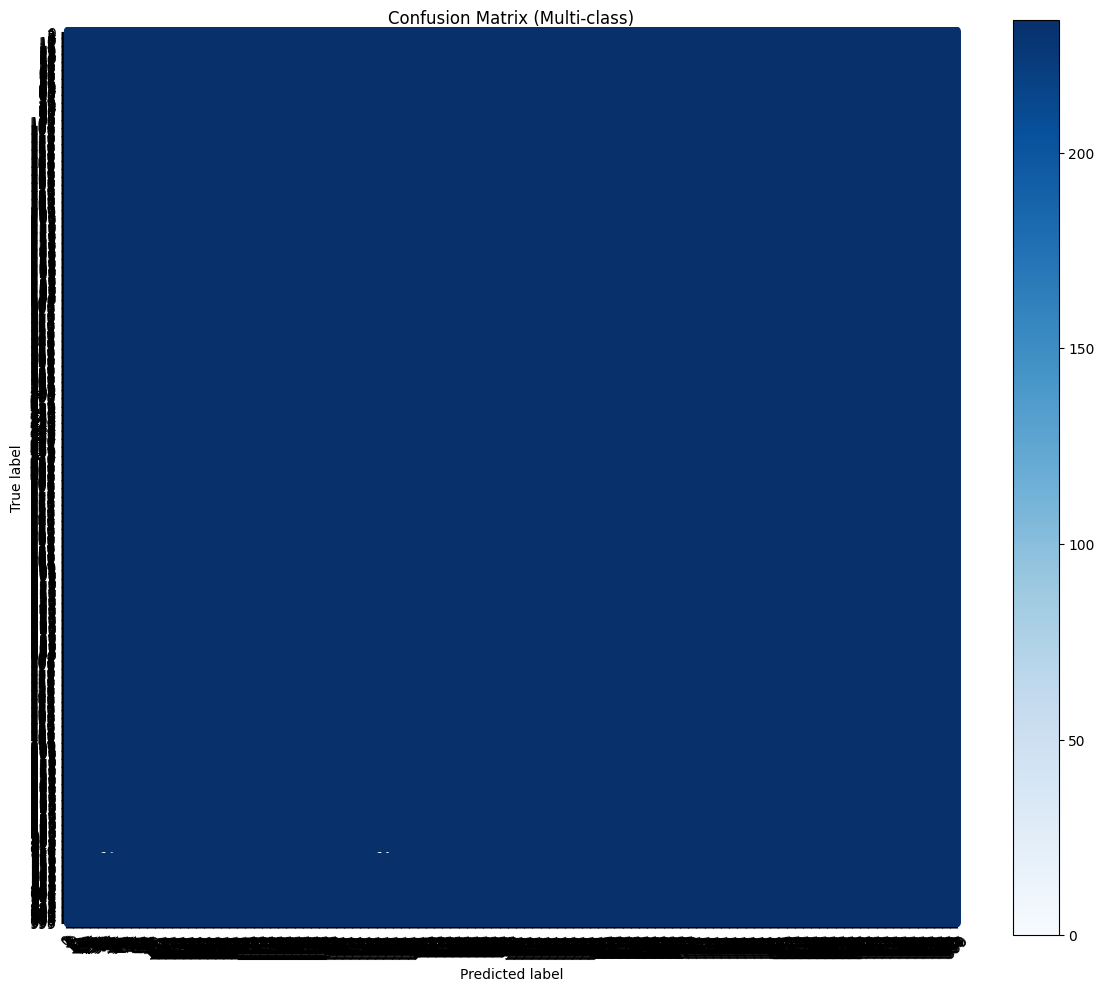

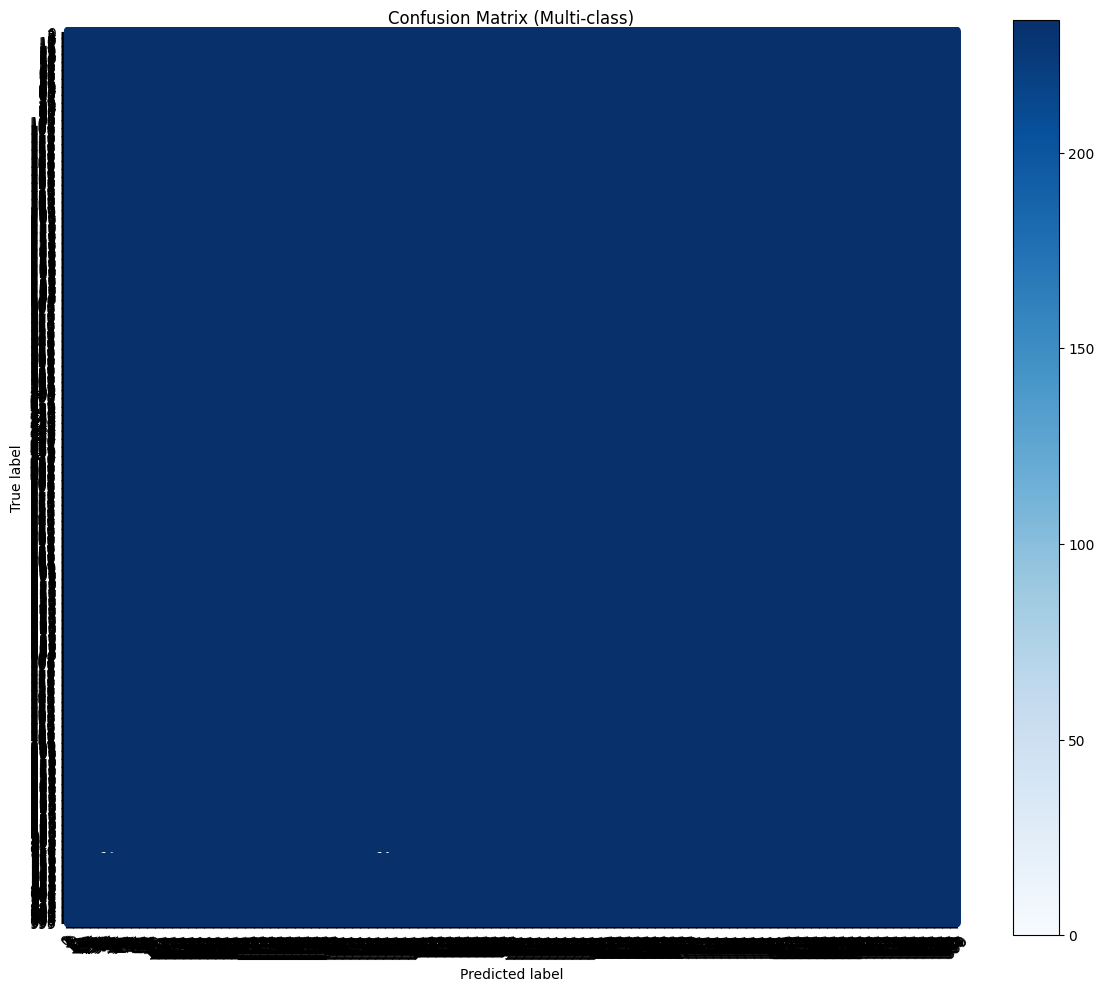

In [ ]:
# Con LabelEncoder para recuperar nombres reales de autores
class_names = [str(uid) for uid in label_encoder.classes_]

# Evaluar
matrix, preds = get_confusion_matrix(hnn_model, x_dev, y_dev, class_names)

# Mostrar (con muchos autores quizás no es legible, mejor sin nombres)
display_confusion_matrix(matrix)                         # sin nombres
display_confusion_matrix(matrix, class_names=class_names)  # con nombres



In [ ]:
# Métricas — para authorship con clases desbalanceadas usar "weighted"
results = metrics(matrix, class_names=class_names, average="weighted")


Clase                  Accuracy  Precision     Recall         F1    Support
------------------------------------------------------------------------
0                        0.9954     0.0000     0.0000     0.0000        216
------------------------------------------------------------------------
Global accuracy         0.0008
Average precision    (weighted)     0.0000
Average recall       (weighted)     0.0000
Average F1 score     (weighted)     0.0000


### Test 10 Autores

In [ ]:
df_10 = dev_tokens_users_cleaned['uid'].value_counts().head(10)

In [ ]:
df_test = dev_tokens_users_cleaned[dev_tokens_users_cleaned['uid'].isin(df_10)]

In [ ]:
df_test

,chunk_id,token_ids,num_tokens,uid,pid,tokens_ids_padded,uid_encoded
12470,0,"[101, 1013, 1013, 2074, 2005, 5604, 1012, 1012...",512,319,9413,"[101, 1013, 1013, 2074, 2005, 5604, 1012, 1012...",319
12471,1,"[101, 1050, 1007, 1063, 2709, 13594, 2546, 100...",512,319,9413,"[101, 1050, 1007, 1063, 2709, 13594, 2546, 100...",319
12472,2,"[101, 1027, 17377, 1006, 17350, 1010, 22441, 1...",91,319,9413,"[101, 1027, 17377, 1006, 17350, 1010, 22441, 1...",319
12473,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",512,319,4207,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",319
12474,1,"[101, 2102, 10424, 8780, 11837, 1006, 1000, 10...",74,319,4207,"[101, 2102, 10424, 8780, 11837, 1006, 1000, 10...",319
...,...,...,...,...,...,...,...
46837,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",135,174,36205,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",174
46838,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",235,174,83472,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",174
46839,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",326,174,21467,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",174
46840,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",107,174,35670,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",174


In [ ]:
x_test = df_test['tokens_ids_padded']
x_test = np.array(x_test.tolist())
x_test

array([[  101,  1013,  1013, ...,  2146,  1004,   102],
       [  101,  1050,  1007, ...,  1055,  2487,   102],
       [  101,  1027, 17377, ...,     0,     0,     0],
       ...,
       [  101,  1001,  2421, ...,     0,     0,     0],
       [  101,  1001,  2421, ...,     0,     0,     0],
       [  101,  1001,  2421, ...,     0,     0,     0]])

In [ ]:
y_test = df_test['uid_encoded']
y_test

,uid_encoded
12470,319
12471,319
12472,319
12473,319
12474,319
...,...
46837,174
46838,174
46839,174
46840,174


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


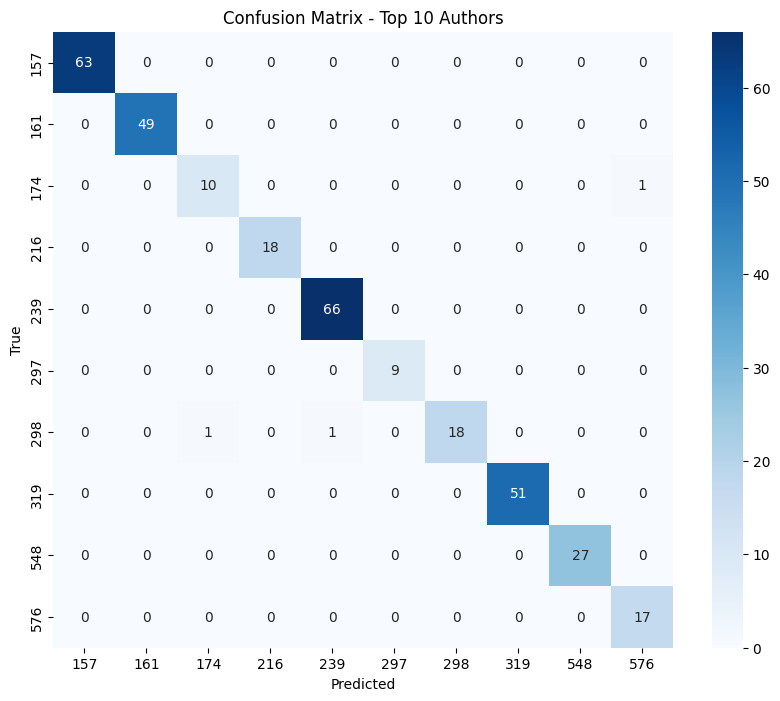

In [ ]:

y_pred_probs = hnn_model_uploaded.predict(x_test)

y_pred = np.argmax(y_pred_probs, axis=1)

labels_top10 = sorted(df_test['uid_encoded'].unique())
cm10 = confusion_matrix(
    y_test,
    y_pred,
    labels=labels_top10
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm10,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_top10,
    yticklabels=labels_top10
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Top 10 Authors")

plt.show()

In [ ]:

results = metrics(cm10, class_names=labels_top10, average="weighted")


Clase                  Accuracy  Precision     Recall         F1    Support
------------------------------------------------------------------------
157                      1.0000     1.0000     1.0000     1.0000         63
161                      1.0000     1.0000     1.0000     1.0000         49
174                      0.9940     0.9091     0.9091     0.9091         11
216                      1.0000     1.0000     1.0000     1.0000         18
239                      0.9970     0.9851     1.0000     0.9925         66
297                      1.0000     1.0000     1.0000     1.0000          9
298                      0.9940     1.0000     0.9000     0.9474         20
319                      1.0000     1.0000     1.0000     1.0000         51
548                      1.0000     1.0000     1.0000     1.0000         27
576                      0.9970     0.9444     1.0000     0.9714         17


In [ ]:
class_names = labels_top10

report = classification_report(
    y_test,
    y_pred,
    target_names=[str(i) for i in class_names],
    labels=class_names
)

print(report)

conf_matrix = confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

         157       0.97      0.67      0.79        94
         161       0.98      0.80      0.88        61
         174       0.91      0.24      0.38        41
         216       1.00      0.36      0.53        50
         239       0.99      0.84      0.90        79
         297       0.90      0.28      0.43        32
         298       1.00      0.51      0.68        35
         319       1.00      0.88      0.94        58
         548       0.96      0.68      0.79        40
         576       0.94      0.61      0.74        28

   micro avg       0.98      0.63      0.77       518
   macro avg       0.97      0.59      0.71       518
weighted avg       0.97      0.63      0.75       518



### 50 Autores

In [ ]:
df_50 = dev_tokens_users_cleaned['uid'].value_counts().head(50)

In [ ]:
df_test50 = dev_tokens_users_cleaned[dev_tokens_users_cleaned['uid'].isin(df_50)]

In [ ]:
df_test50

,chunk_id,token_ids,num_tokens,uid,pid,tokens_ids_padded,uid_encoded
494,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",250,103,20447,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",103
495,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",502,103,94935,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",103
496,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",512,103,62476,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",103
497,1,"[101, 1005, 1038, 1005, 1007, 1063, 1037, 1031...",262,103,62476,"[101, 1005, 1038, 1005, 1007, 1063, 1037, 1031...",103
498,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",408,103,92908,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",103
...,...,...,...,...,...,...,...
46963,1,"[101, 5685, 2222, 10958, 14634, 2094, 1006, 10...",512,149,39053,"[101, 5685, 2222, 10958, 14634, 2094, 1006, 10...",149
46964,2,"[101, 1010, 1047, 1028, 6131, 1006, 1056, 1037...",512,149,39053,"[101, 1010, 1047, 1028, 6131, 1006, 1056, 1037...",149
46965,3,"[101, 1047, 1033, 1012, 1052, 2497, 1006, 1063...",267,149,39053,"[101, 1047, 1033, 1012, 1052, 2497, 1006, 1063...",149
46966,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",168,149,23260,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",149


In [ ]:
x_test = df_test50['tokens_ids_padded']
x_test = np.array(x_test.tolist())
x_test

array([[ 101, 1001, 2421, ...,    0,    0,    0],
       [ 101, 1001, 2421, ...,    0,    0,    0],
       [ 101, 1001, 2421, ...,  999, 1027,  102],
       ...,
       [ 101, 1047, 1033, ...,    0,    0,    0],
       [ 101, 1001, 2421, ...,    0,    0,    0],
       [ 101, 1001, 2421, ...,    0,    0,    0]])

In [ ]:
y_test = df_test50['uid_encoded']
y_test

,uid_encoded
494,103
495,103
496,103
497,103
498,103
...,...
46963,149
46964,149
46965,149
46966,149


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


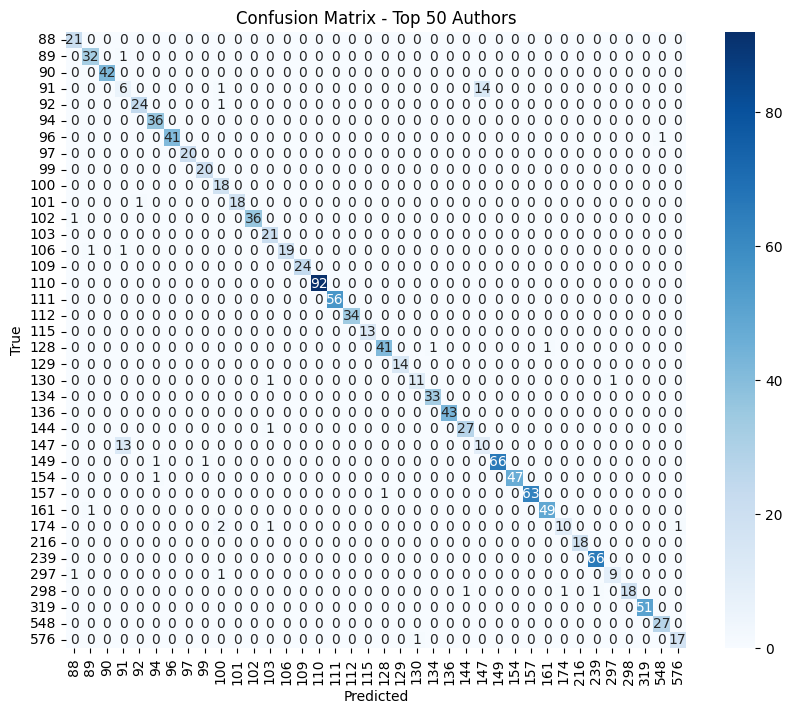

In [ ]:

y_pred_probs = hnn_model_uploaded.predict(x_test)

y_pred = np.argmax(y_pred_probs, axis=1)

labels_top50 = sorted(df_test50['uid_encoded'].unique())
cm50 = confusion_matrix(
    y_test,
    y_pred,
    labels=labels_top50
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm50,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_top50,
    yticklabels=labels_top50
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Top 50 Authors")

plt.show()

In [ ]:

results = metrics(cm50, class_names=labels_top50, average="macro")


Clase                  Accuracy  Precision     Recall         F1    Support
------------------------------------------------------------------------
88                       0.9984     0.9130     1.0000     0.9545         21
89                       0.9976     0.9412     0.9697     0.9552         33
90                       1.0000     1.0000     1.0000     1.0000         42
91                       0.9760     0.2857     0.2857     0.2857         21
92                       0.9984     0.9600     0.9600     0.9600         25
94                       0.9984     0.9474     1.0000     0.9730         36
96                       0.9992     1.0000     0.9762     0.9880         42
97                       1.0000     1.0000     1.0000     1.0000         20
99                       0.9992     0.9524     1.0000     0.9756         20
100                      0.9960     0.7826     1.0000     0.8780         18
101                      0.9992     1.0000     0.9474     0.9730         19
102           

In [ ]:
class_names = labels_top50

report = classification_report(
    y_test,
    y_pred,
    target_names=[str(i) for i in class_names],
    labels=class_names
)

print(report)

conf_matrix = confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

          88       0.91      0.75      0.82        28
          89       0.94      0.64      0.76        50
          90       1.00      0.78      0.88        54
          91       0.29      0.18      0.22        34
          92       0.96      0.65      0.77        37
          94       0.95      0.68      0.79        53
          96       1.00      0.76      0.86        54
          97       1.00      0.62      0.77        32
          99       0.95      0.74      0.83        27
         100       0.78      0.67      0.72        27
         101       1.00      0.60      0.75        30
         102       1.00      0.73      0.85        49
         103       0.88      0.66      0.75        32
         106       1.00      0.59      0.75        32
         109       1.00      0.75      0.86        32
         110       1.00      0.92      0.96       100
         111       1.00      0.81      0.90        69
         112       1.00    

In [ ]:
class_names = labels_top50

report = classification_report(
    y_test,
    y_pred,
    target_names=[str(i) for i in class_names],
    labels=class_names
)

print(report)

conf_matrix = confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

          88       0.91      0.75      0.82        28
          89       0.91      0.64      0.75        50
          90       1.00      0.78      0.88        54
          91       0.29      0.18      0.22        34
          92       0.96      0.65      0.77        37
          94       0.92      0.68      0.78        53
          96       1.00      0.76      0.86        54
          97       1.00      0.62      0.77        32
          99       0.95      0.74      0.83        27
         100       0.69      0.67      0.68        27
         101       1.00      0.60      0.75        30
         102       1.00      0.73      0.85        49
         103       0.88      0.66      0.75        32
         106       1.00      0.59      0.75        32
         109       1.00      0.75      0.86        32
         110       1.00      0.92      0.96       100
         111       1.00      0.81      0.90        69
         112       1.00    

### 100 Autores

In [ ]:
df_100 = dev_tokens_users_cleaned['uid'].value_counts().head(100)

In [ ]:
df_test100 = dev_tokens_users_cleaned[dev_tokens_users_cleaned['uid'].isin(df_100)]

In [ ]:
df_test100

,chunk_id,token_ids,num_tokens,uid,pid,tokens_ids_padded,uid_encoded
494,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",250,103,20447,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",103
495,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",502,103,94935,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",103
496,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",512,103,62476,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",103
497,1,"[101, 1005, 1038, 1005, 1007, 1063, 1037, 1031...",262,103,62476,"[101, 1005, 1038, 1005, 1007, 1063, 1037, 1031...",103
498,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",408,103,92908,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",103
...,...,...,...,...,...,...,...
46963,1,"[101, 5685, 2222, 10958, 14634, 2094, 1006, 10...",512,149,39053,"[101, 5685, 2222, 10958, 14634, 2094, 1006, 10...",149
46964,2,"[101, 1010, 1047, 1028, 6131, 1006, 1056, 1037...",512,149,39053,"[101, 1010, 1047, 1028, 6131, 1006, 1056, 1037...",149
46965,3,"[101, 1047, 1033, 1012, 1052, 2497, 1006, 1063...",267,149,39053,"[101, 1047, 1033, 1012, 1052, 2497, 1006, 1063...",149
46966,0,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",168,149,23260,"[101, 1001, 2421, 1026, 9017, 1013, 2358, 1640...",149


In [ ]:
x_test = df_test100['tokens_ids_padded']
x_test = np.array(x_test.tolist())
x_test

array([[ 101, 1001, 2421, ...,    0,    0,    0],
       [ 101, 1001, 2421, ...,    0,    0,    0],
       [ 101, 1001, 2421, ...,  999, 1027,  102],
       ...,
       [ 101, 1047, 1033, ...,    0,    0,    0],
       [ 101, 1001, 2421, ...,    0,    0,    0],
       [ 101, 1001, 2421, ...,    0,    0,    0]])

In [ ]:
y_test = df_test100['uid_encoded']
y_test

,uid_encoded
494,103
495,103
496,103
497,103
498,103
...,...
46963,149
46964,149
46965,149
46966,149


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


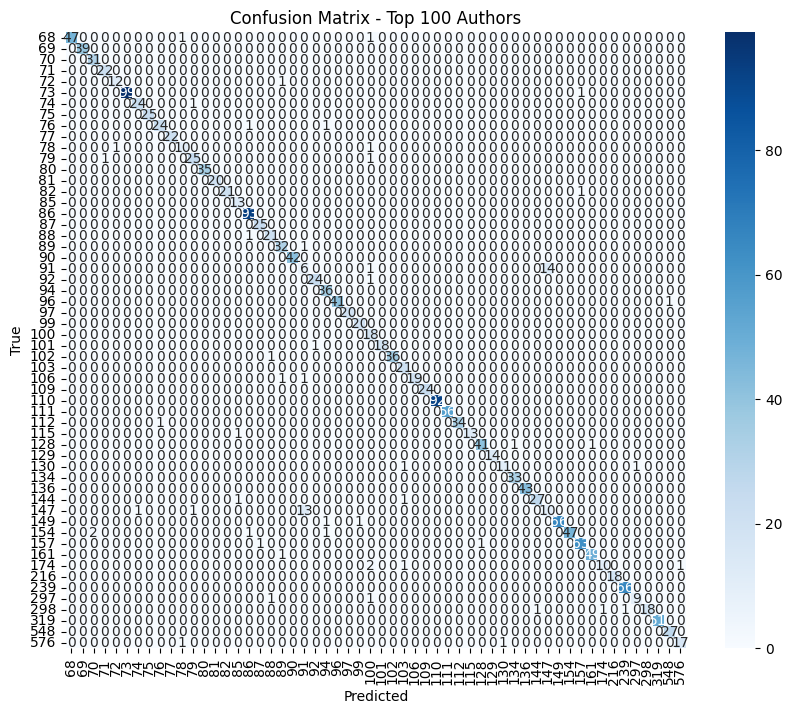

In [ ]:

y_pred_probs = hnn_model_uploaded.predict(x_test)

y_pred = np.argmax(y_pred_probs, axis=1)

labels_top100 = sorted(df_test100['uid_encoded'].unique())
cm100 = confusion_matrix(
    y_test,
    y_pred,
    labels=labels_top100
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm100,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_top100,
    yticklabels=labels_top100
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Top 100 Authors")

plt.show()

In [ ]:

results = metrics(cm100, class_names=labels_top100, average="macro")


Clase                  Accuracy  Precision     Recall         F1    Support
------------------------------------------------------------------------
68                       0.9989     1.0000     0.9592     0.9792         49
69                       1.0000     1.0000     1.0000     1.0000         39
70                       0.9989     0.9394     1.0000     0.9688         31
71                       0.9995     0.9565     1.0000     0.9778         22
72                       0.9989     0.9231     0.9231     0.9231         13
73                       0.9995     1.0000     0.9900     0.9950        100
74                       0.9989     0.9600     0.9600     0.9600         25
75                       1.0000     1.0000     1.0000     1.0000         25
76                       0.9984     0.9600     0.9231     0.9412         26
77                       1.0000     1.0000     1.0000     1.0000         22
78                       0.9978     0.8333     0.8333     0.8333         12
79            

In [ ]:
class_names = labels_top100

report = classification_report(
    y_test,
    y_pred,
    target_names=[str(i) for i in class_names],
    labels=class_names
)

print(report)

conf_matrix = confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

          68       1.00      0.73      0.85        64
          69       1.00      0.70      0.82        56
          70       0.94      0.69      0.79        45
          71       0.96      0.71      0.81        31
          72       0.92      0.39      0.55        31
          73       1.00      0.86      0.93       115
          74       0.96      0.86      0.91        28
          75       1.00      0.93      0.96        27
          76       0.96      0.67      0.79        36
          77       1.00      0.73      0.85        30
          78       0.83      0.36      0.50        28
          79       0.93      0.64      0.76        39
          80       1.00      0.74      0.85        47
          81       1.00      0.53      0.69        38
          82       1.00      0.62      0.76        34
          85       0.87      0.46      0.60        28
          86       0.97      0.85      0.90       110
          87       0.96    

In [ ]:

print(f"Accuracy 1000: {np.trace(matrix) / matrix.sum():.4f}")

print(f"Accuracy 10:   {np.trace(cm10) / cm10.sum():.4f}")

print(f"Accuracy 50:   {np.trace(cm50) / cm50.sum():.4f}")

print(f"Accuracy 100:   {np.trace(cm100) / cm100.sum():.4f}")



Accuracy 1000: nan
Accuracy 10:   0.9909
Accuracy 50:   0.9559
Accuracy 100:   0.9580


/tmp/ipykernel_21434/3159768123.py:2: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Accuracy 1000: {np.trace(matrix) / matrix.sum():.4f}")
